In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import math



In [13]:
train_df = pd.read_csv("Datast/train.csv")
test_df = pd.read_csv("Datast/test.csv")
building_df = pd.read_csv("Datast/building_metadata.csv")
weather_train_df = pd.read_csv("Datast/weather_train.csv")
weather_test_df = pd.read_csv("Datast/weather_test.csv")

In [14]:
wet_cop=weather_train_df.copy()
buil_cop=building_df.copy()

In [15]:
test_wet_cop=weather_test_df.copy()


In [16]:
# wet_cop['year']

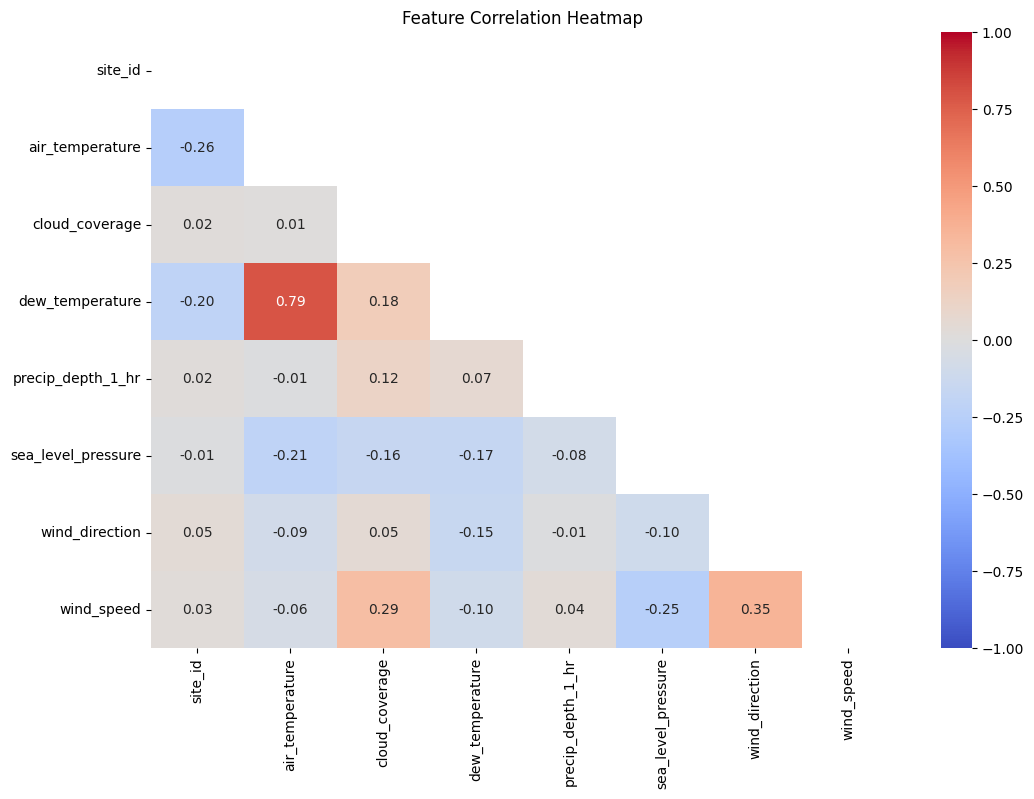

In [17]:
numeric_cols = wet_cop.select_dtypes(include=['float64', 'int64']).columns
corr_df = wet_cop[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    mask=np.triu(np.ones_like(corr_df))  # Hide upper triangle for clarity
)
plt.title("Feature Correlation Heatmap")
plt.show()

In [18]:
def saturation_vapor_pressure(temperature):
    return 6.112 * math.exp((17.67 * temperature) / (temperature + 243.5))

# Function to calculate relative humidity
def relative_humidity(air_temp, dew_temp):
    E_air = saturation_vapor_pressure(air_temp)
    E_dew = saturation_vapor_pressure(dew_temp)
    RH = (E_dew / E_air) * 100
    return RH

# Apply the function to each row in the dataframe to calculate relative humidity
wet_cop['relative_humidity'] = wet_cop.apply(lambda row: relative_humidity(row['air_temperature'], row['dew_temperature']), axis=1)
test_wet_cop['relative_humidity'] = test_wet_cop.apply(lambda row: relative_humidity(row['air_temperature'], row['dew_temperature']), axis=1)

In [19]:
# Simplified heat index (Rothfusz regression approximation)
wet_cop['heat_index'] = (
    0.5 * (wet_cop['air_temperature'] + 61.0 + 
    (wet_cop['air_temperature'] - 68.0) * 1.2 + 
    wet_cop['dew_temperature'] * 0.094
)
)

# Wind chill (for temps < 10°C and wind > 4.8 km/h)
mask = (wet_cop['air_temperature'] < 10) & (wet_cop['wind_speed'] > 1.34)  # 1.34 m/s ≈ 4.8 km/h
wet_cop['wind_chill'] = (
    13.12 + 0.6215 * wet_cop['air_temperature'] - 
    11.37 * (wet_cop['wind_speed'] ** 0.16) + 
    0.3965 * wet_cop['air_temperature'] * (wet_cop['wind_speed'] ** 0.16)
)
wet_cop['wind_chill'] = wet_cop['wind_chill'].where(mask, wet_cop['air_temperature'])

wet_cop['feels_like'] = np.where(
    wet_cop['air_temperature'] >= 27,  # Hot threshold
    wet_cop['heat_index'],
    np.where(
        wet_cop['air_temperature'] <= 10,  # Cold threshold
        wet_cop['wind_chill'],
        wet_cop['air_temperature']  # Default
    )
)

In [20]:
# Simplified heat index (Rothfusz regression approximation)
test_wet_cop['heat_index'] = (
    0.5 * (test_wet_cop['air_temperature'] + 61.0 + 
    (test_wet_cop['air_temperature'] - 68.0) * 1.2 + 
    test_wet_cop['dew_temperature'] * 0.094
)
)

# Wind chill (for temps < 10°C and wind > 4.8 km/h)
mask = (test_wet_cop['air_temperature'] < 10) & (test_wet_cop['wind_speed'] > 1.34)  # 1.34 m/s ≈ 4.8 km/h
test_wet_cop['wind_chill'] = (
    13.12 + 0.6215 * test_wet_cop['air_temperature'] - 
    11.37 * (test_wet_cop['wind_speed'] ** 0.16) + 
    0.3965 * test_wet_cop['air_temperature'] * (test_wet_cop['wind_speed'] ** 0.16)
)
test_wet_cop['wind_chill'] = test_wet_cop['wind_chill'].where(mask, test_wet_cop['air_temperature'])

test_wet_cop['feels_like'] = np.where(
    test_wet_cop['air_temperature'] >= 27,  # Hot threshold
    test_wet_cop['heat_index'],
    np.where(
        test_wet_cop['air_temperature'] <= 10,  # Cold threshold
        test_wet_cop['wind_chill'],
        test_wet_cop['air_temperature']  # Default
    )
)

In [21]:

wet_cop['precip_depth_1_hr'] = (
    wet_cop['precip_depth_1_hr']
    .replace(-1.0, np.nan)
    .interpolate(method='linear', limit=6)  # 6-hour gap limit
    .fillna(0)  # Fill remaining gaps with 0
)

In [22]:

test_wet_cop['precip_depth_1_hr'] = (
    test_wet_cop['precip_depth_1_hr']
    .replace(-1.0, np.nan)
    .interpolate(method='linear', limit=6)  # 6-hour gap limit
    .fillna(0)  # Fill remaining gaps with 0
)

In [23]:
bins = [-0.1, 0.1, 5.0, 15.0, float('inf')]  # -0.1 to catch near-zero values  
labels = ['No Rain', 'Light Rain', 'Moderate Rain', 'Heavy Rain']  

wet_cop['precip_1h_category'] = pd.cut(
    wet_cop['precip_depth_1_hr'],  
    bins=bins,  
    labels=labels  
)

In [24]:
bins = [-0.1, 0.1, 5.0, 15.0, float('inf')]  # -0.1 to catch near-zero values  
labels = ['No Rain', 'Light Rain', 'Moderate Rain', 'Heavy Rain']  

test_wet_cop['precip_1h_category'] = pd.cut(
    test_wet_cop['precip_depth_1_hr'],  
    bins=bins,  
    labels=labels  
)

In [25]:
wet_cop['is_light_rain'] = (wet_cop['precip_depth_1_hr'] > 0.1).astype(int)  
# wet_cop['is_moderate_rain'] = (wet_cop['precip_depth_1_hr'] >= 5 and wet_cop['precip_depth_1_hr'] <15).astype(int)  
wet_cop['is_moderate_rain'] = ((wet_cop['precip_depth_1_hr'] > 0.1) & (wet_cop['precip_depth_1_hr'] < 15.0)).astype(int)

wet_cop['is_heavy_rain'] = (wet_cop['precip_depth_1_hr'] >= 15.0).astype(int)  

In [26]:
test_wet_cop['is_light_rain'] = (test_wet_cop['precip_depth_1_hr'] > 0.1).astype(int)  
# test_wet_cop['is_moderate_rain'] = (test_wet_cop['precip_depth_1_hr'] >= 5 and test_wet_cop['precip_depth_1_hr'] <15).astype(int)  
test_wet_cop['is_moderate_rain'] = ((test_wet_cop['precip_depth_1_hr'] > 0.1) & (test_wet_cop['precip_depth_1_hr'] < 15.0)).astype(int)

test_wet_cop['is_heavy_rain'] = (test_wet_cop['precip_depth_1_hr'] >= 15.0).astype(int)  

In [27]:
Q1 = wet_cop['feels_like'].quantile(0.25)
Q3 = wet_cop['feels_like'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Flag outliers
wet_cop['feels_like_outlier'] = (
    (wet_cop['feels_like'] < lower_bound) | 
    (wet_cop['feels_like'] > upper_bound)
)

print(f"Found {wet_cop['feels_like_outlier'].sum()} outliers.")
print(f"Bounds: [{lower_bound:.1f}°C, {upper_bound:.1f}°C]")

Found 1556 outliers.
Bounds: [-14.2°C, 42.8°C]


In [28]:
T_min = -10  # Below this, heating load is maxed
T_max = 35   # Above this, cooling load is maxed

wet_cop['feels_like_capped'] = wet_cop['feels_like'].clip(T_min, T_max)

In [29]:
rain_types = ['is_light_rain', 'is_moderate_rain', 'is_heavy_rain']
for rain_type in rain_types:
    subset = wet_cop[wet_cop[rain_type] == 1]
    outlier_pct = subset['feels_like_outlier'].mean() * 100
    print(f"{rain_type}: {outlier_pct:.1f}% outliers")

is_light_rain: 2.5% outliers
is_moderate_rain: 3.1% outliers
is_heavy_rain: 0.0% outliers


In [30]:
Q1 = test_wet_cop['feels_like'].quantile(0.25)
Q3 = test_wet_cop['feels_like'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Flag outliers
test_wet_cop['feels_like_outlier'] = (
    (test_wet_cop['feels_like'] < lower_bound) | 
    (test_wet_cop['feels_like'] > upper_bound)
)

print(f"Found {test_wet_cop['feels_like_outlier'].sum()} outliers.")
print(f"Bounds: [{lower_bound:.1f}°C, {upper_bound:.1f}°C]")

Found 3052 outliers.
Bounds: [-14.9°C, 43.7°C]


In [31]:
T_min = -10  # Below this, heating load is maxed
T_max = 35   # Above this, cooling load is maxed

test_wet_cop['feels_like_capped'] = test_wet_cop['feels_like'].clip(T_min, T_max)

In [32]:
rain_types = ['is_light_rain', 'is_moderate_rain', 'is_heavy_rain']
for rain_type in rain_types:
    subset = test_wet_cop[test_wet_cop[rain_type] == 1]
    outlier_pct = subset['feels_like_outlier'].mean() * 100
    print(f"{rain_type}: {outlier_pct:.1f}% outliers")

is_light_rain: 1.0% outliers
is_moderate_rain: 1.3% outliers
is_heavy_rain: 0.0% outliers


In [33]:
final_feat=['site_id','timestamp','air_temperature','sea_level_pressure',
 'wind_direction',
 'wind_speed',
 'relative_humidity',
 'is_light_rain',
 'is_moderate_rain',
 'is_heavy_rain',
 'feels_like_capped']

In [34]:
final_weat_df_train = wet_cop[final_feat].copy()

In [35]:
final_weat_df_test = test_wet_cop[final_feat].copy()

In [36]:
final_weat_df_test.dropna(subset=['sea_level_pressure','wind_direction','wind_speed','relative_humidity','feels_like_capped',"air_temperature"],inplace=True)
final_weat_df_train.dropna(subset=['sea_level_pressure','wind_direction','wind_speed','relative_humidity','feels_like_capped',"air_temperature"],inplace=True)

In [37]:
train_merged = train_df.merge(buil_cop, on="building_id", how="left")
main_merged_train = train_merged.merge(final_weat_df_train, on=["site_id", "timestamp"], how="left",validate='many_to_one')
main_merged_train.shape

(20216100, 18)

In [38]:
test_merged = test_df.merge(buil_cop, on="building_id", how="left")
main_merged_test = train_merged.merge(final_weat_df_test, on=["site_id", "timestamp"], how="left",validate='many_to_one')
main_merged_test.shape

(20216100, 18)

In [39]:
main_merged_train.loc[(main_merged_train["site_id"] == 0) & (main_merged_train["meter"] == 0), "meter_reading"] *= 0.293071

In [40]:
main_merged_train["meter_reading"] = np.log1p(main_merged_train["meter_reading"])


In [41]:
drop_0readings= list(main_merged_train[main_merged_train['meter_reading']==0.0].index)
main_merged_train.drop(drop_0readings, axis=0, inplace=True)

In [42]:
main_merged_train['primary_use'] = main_merged_train['primary_use'].astype('category')
main_merged_train['meter'] = main_merged_train['meter'].astype('category')

test


In [43]:
main_merged_test.loc[(main_merged_test["site_id"] == 0) & (main_merged_test["meter"] == 0), "meter_reading"] *= 0.293071

In [ ]:
main_merged_test["meter_reading"] = np.log1p(main_merged_test["meter_reading"])

In [45]:
drop_0readings= list(main_merged_test[main_merged_test['meter_reading']==0.0].index)
main_merged_test.drop(drop_0readings, axis=0, inplace=True)

In [46]:
main_merged_test['primary_use'] = main_merged_test['primary_use'].astype('category')
main_merged_test['meter'] = main_merged_test['meter'].astype('category')

In [47]:
import numpy as np
import pandas as pd

# Assuming main_merged_train is your weather dataframe
main_merged_train["timestamp"] = pd.to_datetime(main_merged_train["timestamp"])

# Extract basic time features
main_merged_train["hour"] = main_merged_train["timestamp"].dt.hour
main_merged_train["day_of_week"] = main_merged_train["timestamp"].dt.weekday  # Monday=0, Sunday=6
main_merged_train["month"] = main_merged_train["timestamp"].dt.month
main_merged_train["day_of_year"] = main_merged_train["timestamp"].dt.dayofyear
main_merged_train["is_weekend"] = (main_merged_train["day_of_week"] >= 5).astype(int)

# Cyclical encoding for hour
main_merged_train["hour_sin"] = np.sin(2 * np.pi * main_merged_train["hour"] / 24)
main_merged_train["hour_cos"] = np.cos(2 * np.pi * main_merged_train["hour"] / 24)

# Cyclical encoding for day of the week
main_merged_train["day_sin"] = np.sin(2 * np.pi * main_merged_train["day_of_week"] / 7)
main_merged_train["day_cos"] = np.cos(2 * np.pi * main_merged_train["day_of_week"] / 7)

# Cyclical encoding for month
main_merged_train["month_sin"] = np.sin(2 * np.pi * main_merged_train["month"] / 12)
main_merged_train["month_cos"] = np.cos(2 * np.pi * main_merged_train["month"] / 12)

# Season encoding (0: Winter, 1: Spring, 2: Summer, 3: Fall)
main_merged_train["season"] = main_merged_train["month"].map(lambda m: 0 if m in [12, 1, 2] else
                                         1 if m in [3, 4, 5] else
                                         2 if m in [6, 7, 8] else 3)

# Drop original timestamp column if no longer needed
main_merged_train.drop(columns=["timestamp"], inplace=True)

# Display updated dataframe
main_merged_train.head()


,building_id,meter,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,sea_level_pressure,...,month,day_of_year,is_weekend,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,season
45,46,0,2.809584,0,Retail,9045,2016.0,NaN,25.0,1019.7,...,1,1,0,0.0,1.0,-0.433884,-0.900969,0.5,0.866025,0
72,74,0,2.610249,0,Parking,387638,1997.0,NaN,25.0,1019.7,...,1,1,0,0.0,1.0,-0.433884,-0.900969,0.5,0.866025,0
91,93,0,2.795020,0,Office,33370,1982.0,NaN,25.0,1019.7,...,1,1,0,0.0,1.0,-0.433884,-0.900969,0.5,0.866025,0
103,105,0,3.190624,1,Education,50623,NaN,5.0,3.8,1020.9,...,1,1,0,0.0,1.0,-0.433884,-0.900969,0.5,0.866025,0
104,106,0,0.318163,1,Education,5374,NaN,4.0,3.8,1020.9,...,1,1,0,0.0,1.0,-0.433884,-0.900969,0.5,0.866025,0


In [48]:
import numpy as np
import pandas as pd

# Assuming main_merged_test is your weather dataframe
main_merged_test["timestamp"] = pd.to_datetime(main_merged_test["timestamp"])

# Extract basic time features
main_merged_test["hour"] = main_merged_test["timestamp"].dt.hour
main_merged_test["day_of_week"] = main_merged_test["timestamp"].dt.weekday  # Monday=0, Sunday=6
main_merged_test["month"] = main_merged_test["timestamp"].dt.month
main_merged_test["day_of_year"] = main_merged_test["timestamp"].dt.dayofyear
main_merged_test["is_weekend"] = (main_merged_test["day_of_week"] >= 5).astype(int)

# Cyclical encoding for hour
main_merged_test["hour_sin"] = np.sin(2 * np.pi * main_merged_test["hour"] / 24)
main_merged_test["hour_cos"] = np.cos(2 * np.pi * main_merged_test["hour"] / 24)

# Cyclical encoding for day of the week
main_merged_test["day_sin"] = np.sin(2 * np.pi * main_merged_test["day_of_week"] / 7)
main_merged_test["day_cos"] = np.cos(2 * np.pi * main_merged_test["day_of_week"] / 7)

# Cyclical encoding for month
main_merged_test["month_sin"] = np.sin(2 * np.pi * main_merged_test["month"] / 12)
main_merged_test["month_cos"] = np.cos(2 * np.pi * main_merged_test["month"] / 12)

# Season encoding (0: Winter, 1: Spring, 2: Summer, 3: Fall)
main_merged_test["season"] = main_merged_test["month"].map(lambda m: 0 if m in [12, 1, 2] else
                                         1 if m in [3, 4, 5] else
                                         2 if m in [6, 7, 8] else 3)

# Drop original timestamp column if no longer needed
main_merged_test.drop(columns=["timestamp"], inplace=True)

# Display updated dataframe
main_merged_test.head()


,building_id,meter,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,sea_level_pressure,...,month,day_of_year,is_weekend,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,season
45,46,0,2.809584,0,Retail,9045,2016.0,NaN,NaN,NaN,...,1,1,0,0.0,1.0,-0.433884,-0.900969,0.5,0.866025,0
72,74,0,2.610249,0,Parking,387638,1997.0,NaN,NaN,NaN,...,1,1,0,0.0,1.0,-0.433884,-0.900969,0.5,0.866025,0
91,93,0,2.795020,0,Office,33370,1982.0,NaN,NaN,NaN,...,1,1,0,0.0,1.0,-0.433884,-0.900969,0.5,0.866025,0
103,105,0,3.190624,1,Education,50623,NaN,5.0,NaN,NaN,...,1,1,0,0.0,1.0,-0.433884,-0.900969,0.5,0.866025,0
104,106,0,0.318163,1,Education,5374,NaN,4.0,NaN,NaN,...,1,1,0,0.0,1.0,-0.433884,-0.900969,0.5,0.866025,0


In [49]:
# features = ["meter", "hour", "day", "month", "weekend",'sea_level_pressure']
features=['building_id', 'meter','site_id', 'primary_use',
       'square_feet', 'year_built',
       'sea_level_pressure', 'wind_direction', 'wind_speed',
       'relative_humidity', 'is_light_rain', 'is_moderate_rain',
       'is_heavy_rain', 'feels_like_capped', 'hour', 'day_of_week', 'month',
       'day_of_year', 'is_weekend', 'hour_sin', 'hour_cos', 'day_sin',
       'day_cos', 'month_sin', 'month_cos', 'season']
target = "meter_reading"

X_train = main_merged_train[features]
y_train = main_merged_train[target]
x_test=main_merged_test[features]
y_test=main_merged_test[target]
# Split into training and validation sets
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


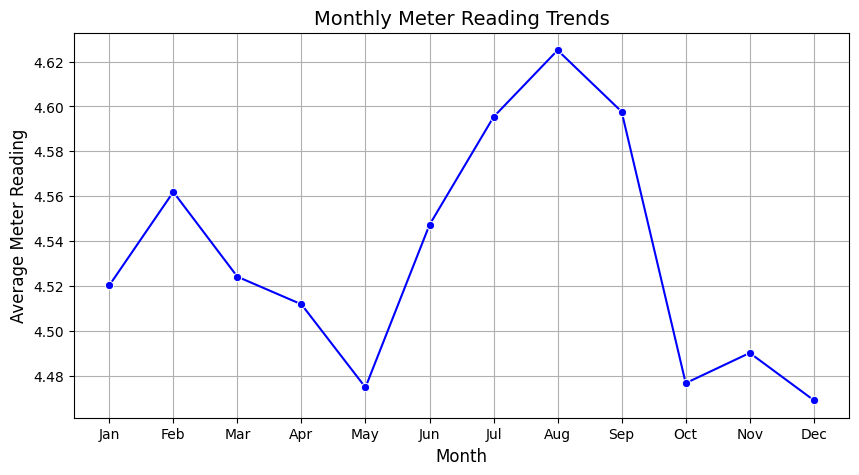

In [54]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# col=main_merged_train.select_dtypes(include=['float64', 'int64']).columns
# # Select only numerical columns
# # numeric_cols = cp_main.select_dtypes(include=["number"]).columns
# # col=['meter_reading', 'square_feet', 'year_built', 'floor_count','air_temperature', 'cloud_coverage', 'dew_temperature','precip_depth_1_hr', 'sea_level_pressure', 'wind_direction','wind_speed']

# # Plot each column separately
# for col in col:
#     plt.figure(figsize=(6, 4))
#     sns.boxplot(x=main_merged_train[col])
#     plt.title(f"Boxplot of {col}")
#     plt.show()

# main_merged_train['meter_reading'].hist(bins=5000)

monthly_readings = main_merged_train.groupby("month")["meter_reading"].mean()

# Plot
plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_readings.index, y=monthly_readings.values, marker="o", linestyle="-", color="b")

# Labels and title
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Meter Reading", fontsize=12)
plt.title("Monthly Meter Reading Trends", fontsize=14)
plt.xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.grid(True)

# Show plot
plt.show()

In [46]:
def rmsle_lgbm(y_pred, data):

    y_true = np.array(data.get_label())
    score = np.sqrt(np.mean(np.power(np.log1p(y_true) - np.log1p(y_pred), 2)))

    return 'rmsle', score, False


In [47]:
params = {
    "objective": "regression",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "n_estimators": 1000,
    "verbose": -1
}

# Convert to LightGBM dataset
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(x_test, label=y_test, reference=train_data)

# Train the model
# model = lgb.train(params, train_data, valid_sets=[val_data], early_stopping_rounds=50, verbose_eval=100)
model = lgb.train(
    params,
    train_data,
    valid_sets=[val_data],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(100)],
    feval=rmsle_lgbm
)


Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 1.04312	valid_0's rmsle: 0.243354
[200]	valid_0's l2: 0.853704	valid_0's rmsle: 0.223575
[300]	valid_0's l2: 0.7372	valid_0's rmsle: 0.210697
[400]	valid_0's l2: 0.670278	valid_0's rmsle: 0.202049
[500]	valid_0's l2: 0.615092	valid_0's rmsle: 0.194578
[600]	valid_0's l2: 0.573329	valid_0's rmsle: 0.189124
[700]	valid_0's l2: 0.548634	valid_0's rmsle: 0.18538
[800]	valid_0's l2: 0.523545	valid_0's rmsle: 0.181625
[900]	valid_0's l2: 0.501061	valid_0's rmsle: 0.178418
[1000]	valid_0's l2: 0.481401	valid_0's rmsle: 0.17526
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l2: 0.481401	valid_0's rmsle: 0.17526


In [48]:
from sklearn.metrics import r2_score
y_train_pred = model.predict(X_train)

# Calculate R² Score
r2 = r2_score(y_train, y_train_pred)
print("Training R² Score:", r2)
y_test_pred = model.predict(x_test)

# Calculate R² Score
r2_test = r2_score(y_test, y_test_pred)
print("Test R² Score:", r2_test)

Training R² Score: 0.8776720384650047
Test R² Score: 0.8461411804105544


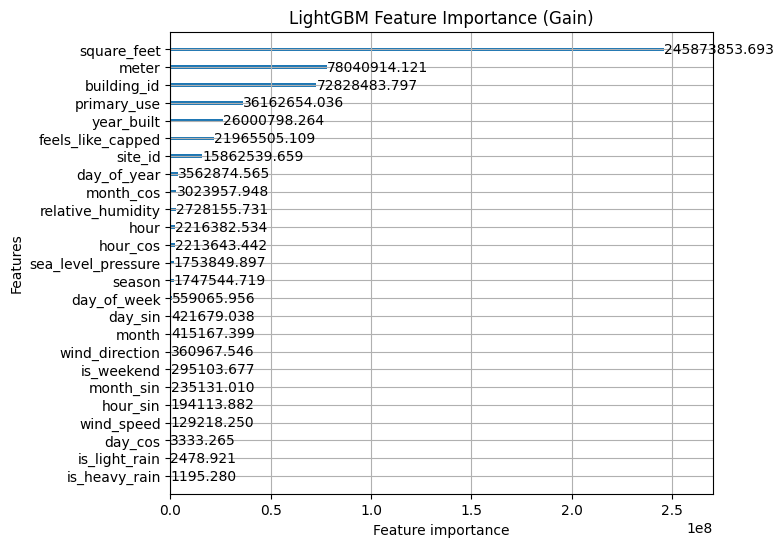

In [49]:
lgb.plot_importance(model, importance_type="gain", figsize=(7,6), title="LightGBM Feature Importance (Gain)")
plt.show()